# Necessary Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Softmax Regression



# Decision Function
* Softmax Function
* Predictive Function

**Softmax Function**

Softmax function is like a extensive sigmoid function where instead of 2 probable outputs, it has multiple output distribution.<br>
Total probability sums to 1.

In [2]:
import numpy as np

def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
    z (numpy.ndarray): Logits (raw scores) of shape (m, n)

    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n)
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Test Softmax Function
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

# Verify if the sum of probabilities for each row is 1
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")


Softmax function passed the test case!


Predictive Function

This function is helpful to predict which class is most probable by selecting the class with highest probability.

In [3]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    numpy.ndarray: Predicted class labels of shape (n,)
    """
    logits = np.dot(X, W) + b
    probabilities = softmax(logits)
    return np.argmax(probabilities, axis=1)  # Select highest probability class

# Test Prediction Function
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])  # Feature matrix
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])    # Weights
b_test = np.array([0.1, 0.2, 0.3])                        # Bias

y_pred_test = predict_softmax(X_test, W_test, b_test)

# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)


Predicted class labels: [1 1 0]


# Implementation of Loss and Cost Function

Loss function means a error calculation with a sample data.

In [4]:
def loss_softmax(y_pred, y_true):
    """
    Compute the cross-entropy loss for a single sample.

    Parameters:
    y_pred (numpy.ndarray): Predicted probabilities of shape (n, c)
    y_true (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)

    Returns:
    float: Average cross-entropy loss.
    """
    m = y_true.shape[0]  # Number of samples
    loss = -np.sum(y_true * np.log(y_pred + 1e-9)) / m  # Add small value to avoid log(0)
    return loss

# Test Loss Function
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])  # One-hot encoded true labels
y_pred_correct = np.array([[0.9, 0.05, 0.05], [0.1, 0.85, 0.05], [0.05, 0.1, 0.85]])  # Correct prediction
y_pred_incorrect = np.array([[0.05, 0.05, 0.9], [0.1, 0.05, 0.85], [0.85, 0.1, 0.05]])  # Incorrect prediction

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, f"Test failed: Expected loss_correct < loss_incorrect, but got {loss_correct:.4f} >= {loss_incorrect:.4f}"

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")


Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


Cost Function is a whole set of data aka. model in most case, a collective error average

In [5]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss).

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    float: Average softmax cost (cross-entropy loss)
    """
    m = X.shape[0]  # Number of samples
    logits = np.dot(X, W) + b  # Compute logits
    y_pred = softmax(logits)  # Get predicted probabilities
    cost = loss_softmax(y_pred, y)  # Compute loss
    return cost

# Test Cost Function
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])  # Features
y_correct = np.array([[1, 0], [0, 1]])  # True labels
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])  # Weights
b_correct = np.array([0.1, 0.1])  # Bias

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])  # Features for incorrect predictions
y_incorrect = np.array([[1, 0], [0, 1]])  # True labels
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])  # Incorrect weights
b_incorrect = np.array([0.5, 0.6])  # Incorrect bias

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, f"Test failed: Expected cost_incorrect > cost_correct"

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")


Cost for correct prediction: 0.0006234354127112888
Cost for incorrect prediction: 0.2993086122417495
Test passed!


# Implementation of Gradient Descent Algorithm

* Choose initial parameters values (weights and bias for each classes)
* Calculate fradient of cost function with respect to each parameter.<br>
``` Gradient is a vector of partial derivatives pointing in the direction of the sttepest increase of the cost function```
* Update the parameters in the direction of negative gradient controlled by learning rate
* Repeat until convergence <br>
``` Convergence Criteria ```

Implementation of Compute Gradients

In [6]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function with respect to weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    tuple: Gradients with respect to weights (d, c) and biases (c,)
    """
    m = X.shape[0]  # Number of samples
    logits = np.dot(X, W) + b  # Compute logits
    y_pred = softmax(logits)  # Get predicted probabilities

    grad_W = np.dot(X.T, (y_pred - y)) / m  # Compute gradient w.r.t W
    grad_b = np.sum(y_pred - y, axis=0) / m  # Compute gradient w.r.t b

    return grad_W, grad_b

# Test Compute Gradient Function
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])  # Feature matrix
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])  # True one-hot labels
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])  # Weights
b_test = np.array([0.1, 0.2, 0.3])  # Bias

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Gradient computation successful!")


Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Gradient computation successful!


Implementation of Gradient Descent Algorithm

In [7]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)
    alpha (float): Learning rate
    n_iter (int): Number of iterations
    show_cost (bool): Whether to display the cost at intervals

    Returns:
    tuple: Optimized weights, biases, and cost history
    """
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)  # Compute gradients

        W -= alpha * grad_W  # Update weights
        b -= alpha * grad_b  # Update biases

        cost = cost_softmax(X, y, W, b)  # Compute cost
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}")

    return W, b, cost_history

# Test Gradient Descent
alpha = 0.1  # Learning rate
n_iter = 1000  # Number of iterations
W_opt, b_opt, cost_history = gradient_descent_softmax(X_test, y_test, W_test, b_test, alpha, n_iter, show_cost=True)

print("Final optimized weights:", W_opt)
print("Final optimized biases:", b_opt)


Iteration 0: Cost = 1.1524
Iteration 100: Cost = 0.7781
Iteration 200: Cost = 0.6227
Iteration 300: Cost = 0.5344
Iteration 400: Cost = 0.4740
Iteration 500: Cost = 0.4283
Iteration 600: Cost = 0.3917
Iteration 700: Cost = 0.3612
Iteration 800: Cost = 0.3352
Iteration 900: Cost = 0.3126
Final optimized weights: [[-3.71426723  0.52161722  3.89265   ]
 [ 4.35110944  0.86918154 -3.72029098]]
Final optimized biases: [ 0.03684221  0.69079876 -0.12764097]


# Preparing dataset

**Question - 1:**
Is extracting pixel values sufficient for effective feature extraction? Why or why not?<br> **Answer:**
In Mnist dataset, yes it is sufficient because the pixel is bound to 28 x 28 pixels and it has a specific range of data to process (0 to 9)
<br>
But for complex images in real world:<br>
* Images are too complex and it struggles with variations
* There is no specific relationship among pixels one another
* And better alternatives exists

Load and Prepare Mnist Dataset

What we are doing in dataset preparation
* Load Mnist csv into pandas dataframe
* Extract labels and pixe values
* Normalise Pixel values
* Plot for one example image per digit for visualisation

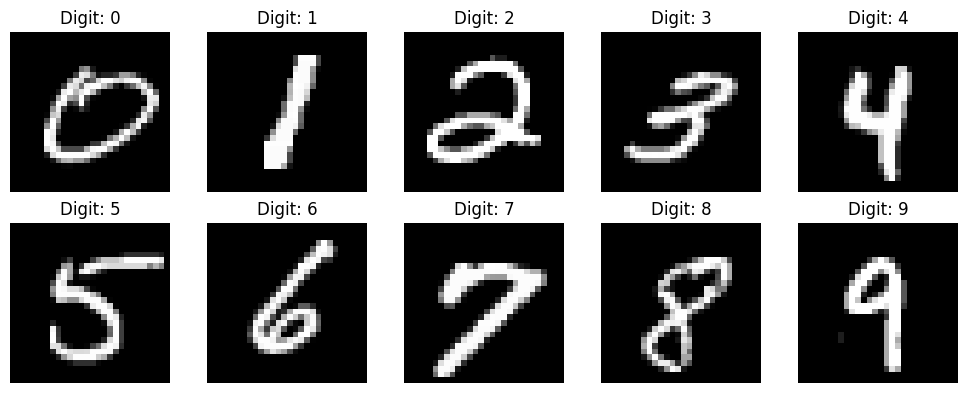

In [11]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets, and plots sample images.

    Parameters:
    csv_file (str): Path to the CSV file containing MNIST data.
    test_size (float): Proportion of data used for testing (default: 0.2).
    random_state (int): Random seed for reproducibility.

    Returns:
    X_train, X_test, y_train, y_test: Split dataset.
    """
    # Load dataset
    df = pd.read_csv(csv_file)

    # Separate labels and features
    y = df.iloc[:, 0].values  # First column is the label
    X = df.iloc[:, 1:].values  # Remaining columns are pixel values

    # Normalize pixel values (optional but recommended)
    X = X / 255.0  # Scale values between 0 and 1

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Plot sample images to verify
    plot_sample_images(X_train, y_train)

    return X_train, X_test, y_train, y_test

# Function to plot sample images
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).

    Parameters:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)  # Get unique class labels

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]  # Find first occurrence of the class
        image = X[index].reshape(28, 28)  # Reshape 1D array to 28x28 pixels

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Digit: {digit}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Load and prepare MNIST dataset (Provide the correct CSV file path)
csv_file = "mnist_dataset.csv"  # Change to the actual file path
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)


# Training the model

One hot encoder is used in converting a categorical data into a binary vector meaning only specific fields are 1 and all other are 0.

Training of softmax regression model

Iteration 0: Cost = 2.2202
Iteration 100: Cost = 0.6087
Iteration 200: Cost = 0.4903
Iteration 300: Cost = 0.4415
Iteration 400: Cost = 0.4133
Iteration 500: Cost = 0.3944
Iteration 600: Cost = 0.3805
Iteration 700: Cost = 0.3697
Iteration 800: Cost = 0.3611
Iteration 900: Cost = 0.3539


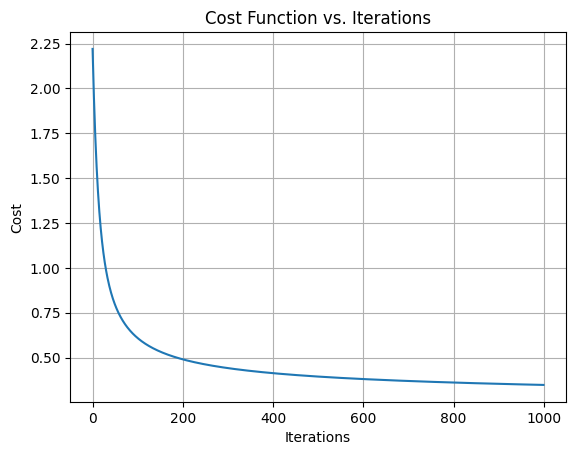

In [12]:
# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))  # Convert labels to one-hot vectors
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Initialize parameters
d = X_train.shape[1]  # Number of features (784 for MNIST)
c = y_train_encoded.shape[1]  # Number of classes (10 for MNIST)

np.random.seed(42)  # Ensure reproducibility
W = np.random.randn(d, c) * 0.01  # Small random values for weights
b = np.zeros(c)  # Bias initialized to 0

# Set hyperparameters
alpha = 0.1  # Learning rate
n_iter = 1000  # Number of iterations

# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train_encoded, W, b, alpha, n_iter, show_cost=True)

# Plot cost vs. iterations to visualize training progress
plt.plot(cost_history)
plt.title("Cost Function vs. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()


Model Performance evaluation


Confusion Matrix:
[[1126    0    5    2    3   13    9    2   12    3]
 [   0 1275    7   11    1    5    1    4   17    1]
 [   2   17 1028   16   19    3   26   24   32    7]
 [   8    6   33 1050    1   53    9    8   30   21]
 [   1    5    7    1 1092    0   10    4    4   52]
 [  22   15   12   41   12  922   14    7   44   15]
 [   6    2   10    1   11   15 1120    2   10    0]
 [   7   27   24    4   15    3    0 1180    7   32]
 [   9   27   14   35    9   33   12    6 1000   15]
 [   8    6   10   18   42    9    0   39   10 1052]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


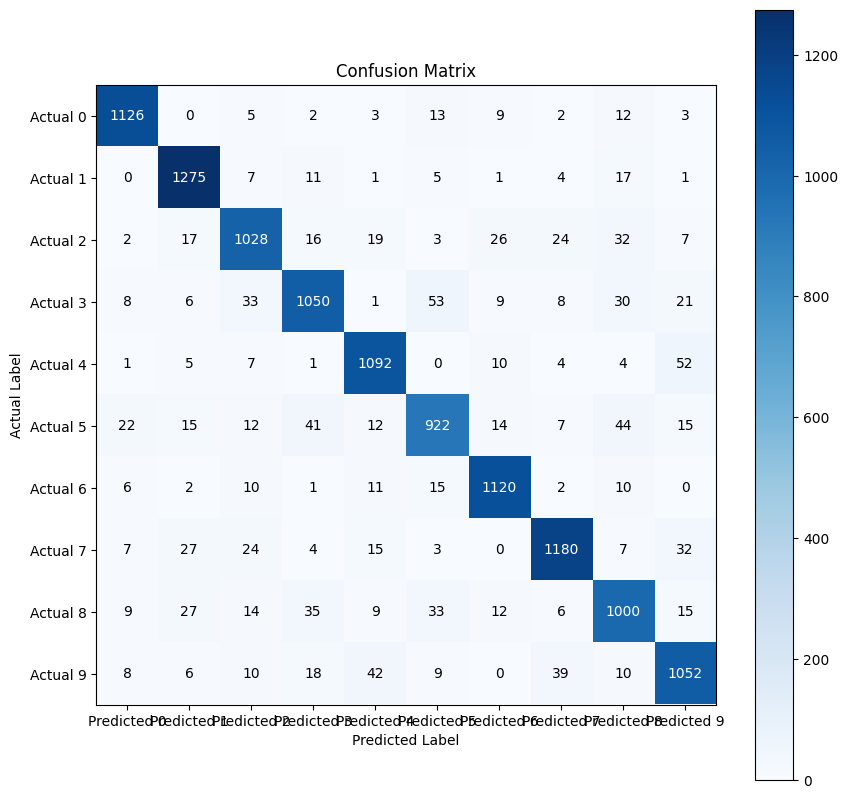

In [13]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1-score
    """
    cm = confusion_matrix(y_true, y_pred)  # Compute confusion matrix
    precision = precision_score(y_true, y_pred, average='weighted')  # Precision
    recall = recall_score(y_true, y_pred, average='weighted')  # Recall
    f1 = f1_score(y_true, y_pred, average='weighted')  # F1-score

    return cm, precision, recall, f1

# Make predictions on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)  # Get predicted labels
y_test_labels = np.argmax(y_test_encoded, axis=1)  # Convert one-hot to class index

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print results
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

# Add text to confusion matrix cells
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar(cax)
plt.show()


# Linear Separability and Logistic Regression

In [14]:
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate linearly separable dataset
X_linear, y_linear = make_classification(n_samples=200, n_features=2,
                                         n_informative=2, n_redundant=0,
                                         n_clusters_per_class=1, random_state=42)

# Split data into train and test sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42)

# Train Logistic Regression on Linearly Separable Data
logistic_model_linear = LogisticRegression()
logistic_model_linear.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset
X_non_linear, y_non_linear = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

# Split data into train and test sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear, y_non_linear, test_size=0.2, random_state=42)

# Train Logistic Regression on Non-Linearly Separable Data
logistic_model_non_linear = LogisticRegression()
logistic_model_non_linear.fit(X_train_non_linear, y_train_non_linear)


LogisticRegression()

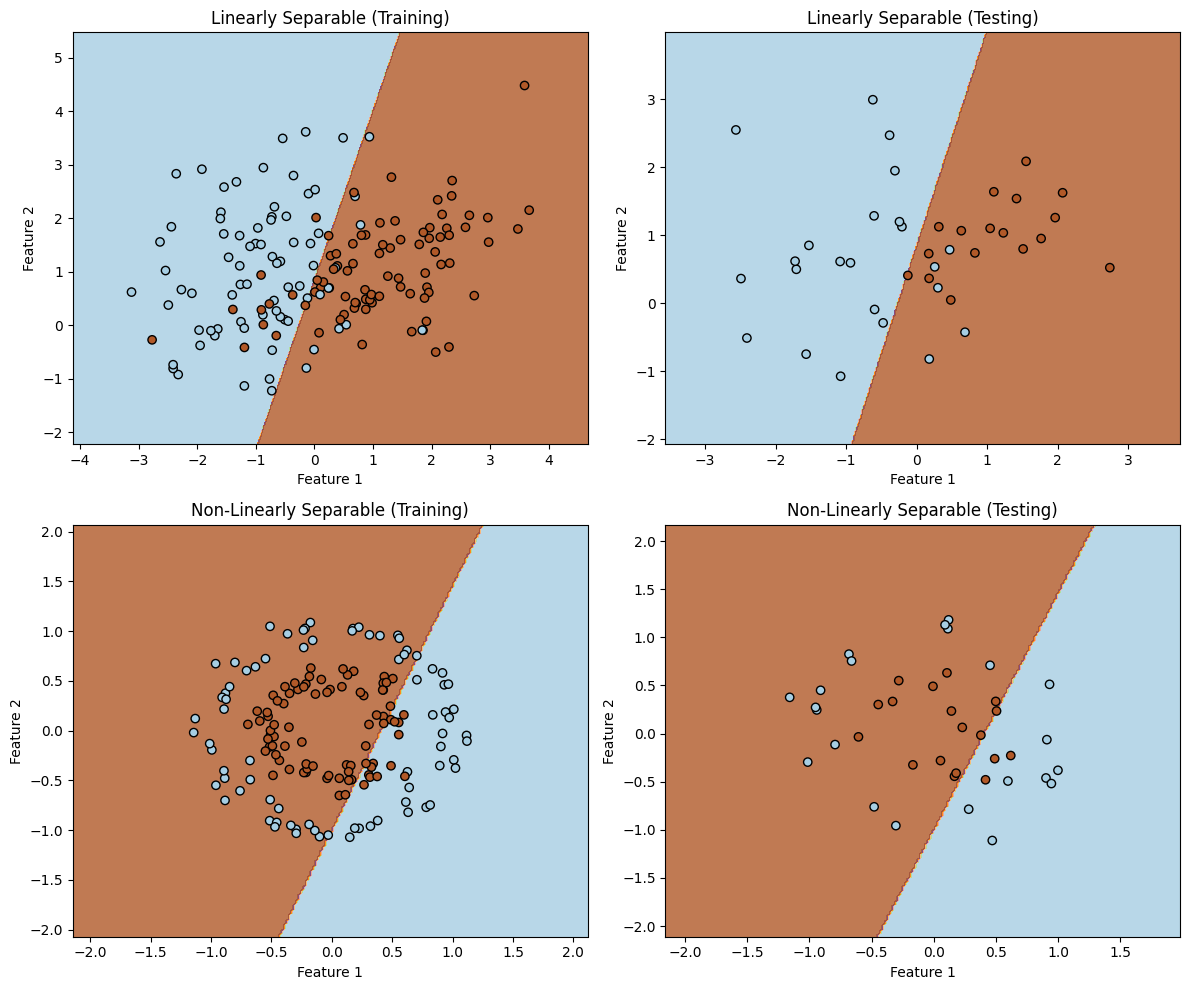

In [15]:
def plot_decision_boundary(ax, model, X, y, title):
    """
    Plots decision boundary of a trained logistic regression model.

    Parameters:
    ax : Matplotlib axis object
    model : Trained LogisticRegression model
    X : Feature matrix (n, 2)
    y : Labels (n,)
    title : Title for the plot
    """
    h = 0.02  # Step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot linearly separable decision boundaries
plot_decision_boundary(axes[0, 0], logistic_model_linear, X_train_linear, y_train_linear, "Linearly Separable (Training)")
plot_decision_boundary(axes[0, 1], logistic_model_linear, X_test_linear, y_test_linear, "Linearly Separable (Testing)")

# Plot non-linearly separable decision boundaries
plot_decision_boundary(axes[1, 0], logistic_model_non_linear, X_train_non_linear, y_train_non_linear, "Non-Linearly Separable (Training)")
plot_decision_boundary(axes[1, 1], logistic_model_non_linear, X_test_non_linear, y_test_non_linear, "Non-Linearly Separable (Testing)")

plt.tight_layout()
plt.savefig("decision_boundaries.png")  # Save plot as PNG
plt.show()


# Expected Output
You should see:

1. A clear separation of two classes in the linearly separable dataset.
2. A poorly learned decision boundary in the non-linearly separable dataset (since Logistic Regression struggles with non-linear data).

# Final Questions

Q2: Provide an interpretation of the output based on your understanding.<br>
1. The confusion matrix shows how well the model classifies each digit.
 * High diagonal values → Good classification accuracy.
 * Off-diagonal values → Misclassified digits (e.g., ‘4’ mistaken as ‘9’).
2. The precision, recall, and F1-score indicate overall performance:
 * High scores (~0.9 or above) → Good classification.
 * Low scores (~0.7 or below) → Model needs improvement.
3. The decision boundary plots:
 * For linearly separable data: Logistic Regression successfully separates classes.
 * For non-linearly separable data: The decision boundary fails to capture the circular pattern, proving Logistic Regression struggles with non-linear relationships.



Q3: Describe any challenges you faced while implementing the code above.
<br>**Answer:**
Some common challenges include:

* Numerical Stability in Softmax – Direct exponentiation can cause overflow. This is fixed by subtracting np.max(z, axis=1, keepdims=True).
* One-Hot Encoding Issues – Forgetting to convert labels properly can cause errors in loss calculations.
* Gradient Descent Convergence – Choosing the right learning rate (
𝛼
α) is crucial:
 * Too high → Divergence.
 * Too low → Slow training.
* Misclassified Digits – Certain digits (e.g., ‘3’ vs. ‘8’) look similar, leading to errors in the confusion matrix.
* Decision Boundaries for Non-Linear Data – Logistic Regression fails on non-linear data, requiring non-linear classifiers like Neural Networks or SVM with RBF Kernel.